In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import BatchNormalization, MaxPooling2D, AveragePooling2D, Flatten, Dense, Conv2D, ZeroPadding2D, Activation, Input, Dropout, Add
from tensorflow.keras.utils import to_categorical
#from keras.initializers import glorot_uniform
from keras import backend as K

import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

In [ ]:
# check for sure if channels should be last - it was changing due to some import
K.image_data_format() == 'channels_first'

False

In [ ]:
import cv2
import os

def load_images(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (80,80))
            images.append(img)

    return np.array(images)

In [ ]:
benign = load_images('/content/drive/MyDrive/Colab Notebooks/dataset/colon_image_sets/colon_n/')
mal_aca = load_images('/content/drive/MyDrive/Colab Notebooks/dataset/colon_image_sets/colon_aca/')

In [ ]:
print(f"Number of images for every class: BENIGN {benign.shape[0]}, ADENOCARCINOMAS {mal_aca.shape[0]}.")

print(f"Images shape: {benign[0].shape}.")

Number of images for every class: BENIGN 5000, ADENOCARCINOMAS 5014.
Images shape: (80, 80, 3).


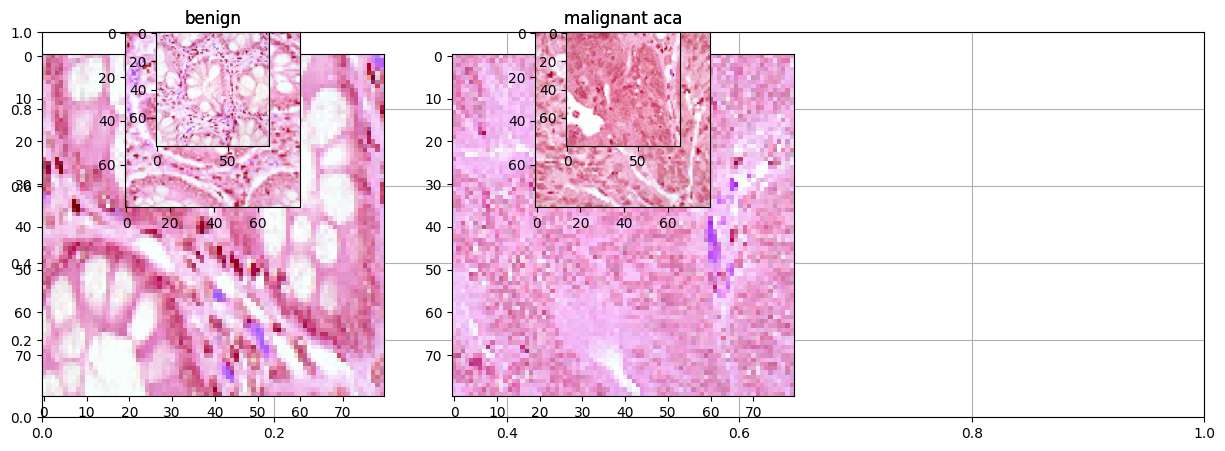

In [ ]:
indices = [0, 40, 2300]

plt.figure(1, figsize=(15,5))
plt.grid(None)

for n, idx in enumerate(indices):
    plt.subplot(n+1, 3, 1)
    plt.imshow(benign[idx])
    plt.title('benign')
    plt.subplot(n+1, 3, 2)
    plt.imshow(mal_aca[idx])
    plt.title('malignant aca')

plt.show()

In [ ]:
samples = np.concatenate((benign, mal_aca))
labels = np.array(benign.shape[0] * [0] + mal_aca.shape[0] * [1])

In [ ]:
print(f"Samples shape check: {samples.shape}.")
print(f"Labels shape check: {labels.shape}.")


Samples shape check: (10014, 80, 80, 3).
Labels shape check: (10014,).


In [ ]:
indices = np.arange(samples.shape[0])
np.random.shuffle(indices)

samples = samples[indices]
labels = labels[indices]

# normalize pictures
samples = samples.astype('float32') / 255

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(samples, labels, test_size = 0.2)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5)

In [ ]:
Y_train = to_categorical(y_train, 2)
Y_val = to_categorical(y_val, 2)
Y_test = to_categorical(y_test, 2)

print(Y_train[0])
print(f"Y_train shape after one hot encoding: {Y_val.shape}")
print(f"Y_train shape after one hot encoding: {X_val.shape}")

[1. 0.]
Y_train shape after one hot encoding: (1001, 2)
Y_train shape after one hot encoding: (1001, 80, 80, 3)


# Model
CNN is used to test image classification consisting of input layer, three hidden conv layers with filter 3x3 each followed by maxpooling with filter 2x2 and dropout 0.2, one fully connected layer and one output layer with 3 units and softmax activation function. For hidden layers relu was used as activation function.

In [ ]:
def base_model(input_shape=(80,80,3), classes=2):
    '''
    CNN base model with 4 hidden layers (3 conv and one fully connected)
    '''
    inputs = Input(shape=input_shape)

    X = Conv2D(32, (3, 3), activation='relu')(inputs)
    X = MaxPooling2D(pool_size=(2,2))(X)

    X = Conv2D(64, (3, 3), activation='relu')(X)
    X = MaxPooling2D(pool_size=(2,2))(X)
    X = Dropout(0.2)(X)

    X = Conv2D(128, (3, 3), activation='relu', padding='same')(X)
    X = MaxPooling2D(pool_size=(2,2), padding='same')(X)
    X = Dropout(0.2)(X)

    X = Flatten()(X)
    X = Dense(256, activation='relu')(X)
    outputs = Dense(classes, activation='softmax')(X)

    model = Model(inputs, outputs)

    return model

In [ ]:
model = base_model(input_shape=(80,80,3), classes=2)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 78, 78, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,226 (10.48 MB)

 Trainable params: 2,748,226 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, Y_train, batch_size=64, epochs=25, validation_data=(X_val, Y_val))

Epoch 1/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 125s 973ms/step - accuracy: 0.5003 - loss: 0.8794 - val_accuracy: 0.5035 - val_loss: 0.6931
Epoch 2/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 142s 976ms/step - accuracy: 0.5130 - loss: 0.6929 - val_accuracy: 0.5035 - val_loss: 0.6920
Epoch 3/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 124s 988ms/step - accuracy: 0.5092 - loss: 0.6876 - val_accuracy: 0.5485 - val_loss: 0.8353
Epoch 4/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7288 - loss: 0.5252 - val_accuracy: 0.7592 - val_loss: 0.4652
Epoch 5/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 118s 936ms/step - accuracy: 0.8294 - loss: 0.3676 - val_accuracy: 0.8621 - val_loss: 0.2918
Epoch 6/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 143s 939ms/step - accuracy: 0.9050 - loss: 0.2334 - val_accuracy: 0.9570 - val_loss: 0.1083
Epoch 7/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 115s 917ms/step - accuracy: 0.9614 - loss: 0.1046 - val_accuracy: 0.9710 - val_loss: 0.0898
Epoch 8/25
126/126 ━━━━━━━━━━━━━━━━━━━━ 146s 952ms/step - accuracy: 0.9599 - lo

# Results

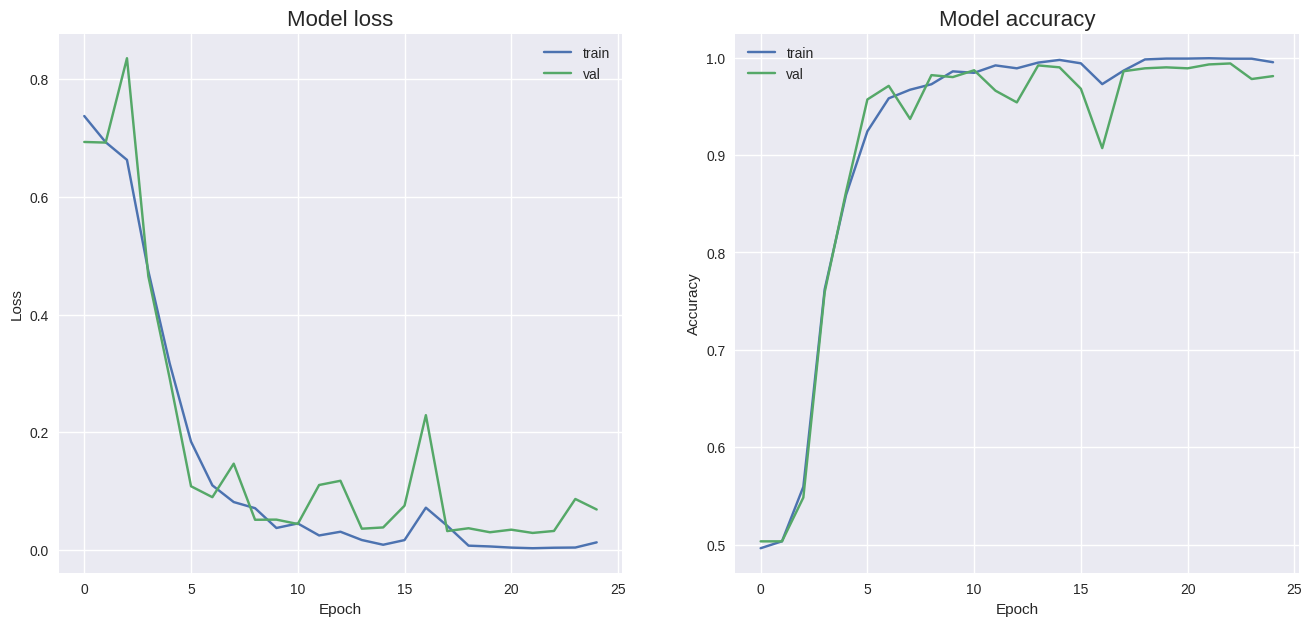

In [ ]:
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(16,7))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss', fontsize=16)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy', fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'])

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

In [ ]:
y_pred_test = model.predict(X_test, verbose=1)
y_pred_train = model.predict(X_train, verbose=1)

# conversion to one hot encoding
#y_pred_test = (y_pred_test > 0.5).astype("int32")
#y_pred_train = (y_pred_train > 0.5).astype("int32")

# convert it to numerical classes
y_pred_test = np.argmax(y_pred_test, axis=1)
y_pred_train = np.argmax(y_pred_train, axis=1)

score_test = model.evaluate(X_test, Y_test)
print(f"Train accuracy: {history.history['accuracy'][-1]:.3f}")
print(f"Validation accuracy: {history.history['val_accuracy'][-1]:.3f}")
print(f"Test accuracy: {score_test[1]:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.9844 - loss: 0.0608
Train accuracy: 0.995
Validation accuracy: 0.981
Test accuracy: 0.986


<Axes: >

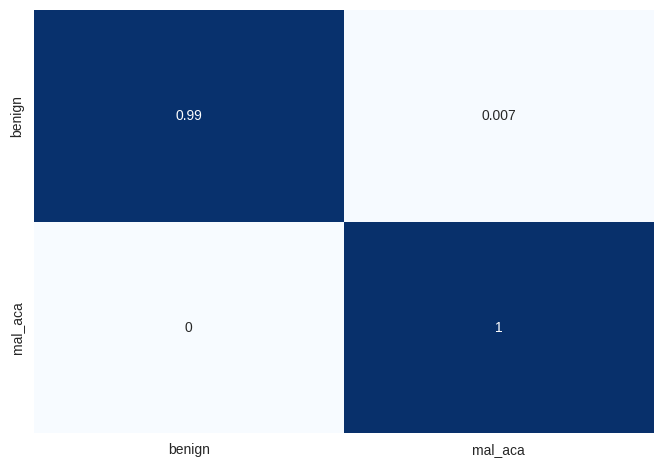

In [ ]:
label_names = ['benign', 'mal_aca']


confmat = confusion_matrix(y_train, y_pred_train, normalize='true')
sn.heatmap(confmat, annot=True, cmap='Blues', cbar=False,
           xticklabels=label_names, yticklabels=label_names)

# Wrongly classified samples
Here I've decided to explore some samples that model didn't get right. Most problems model had with mal_aca class, it mistook it for mal_scc. Run this cell few times to explore different examples.

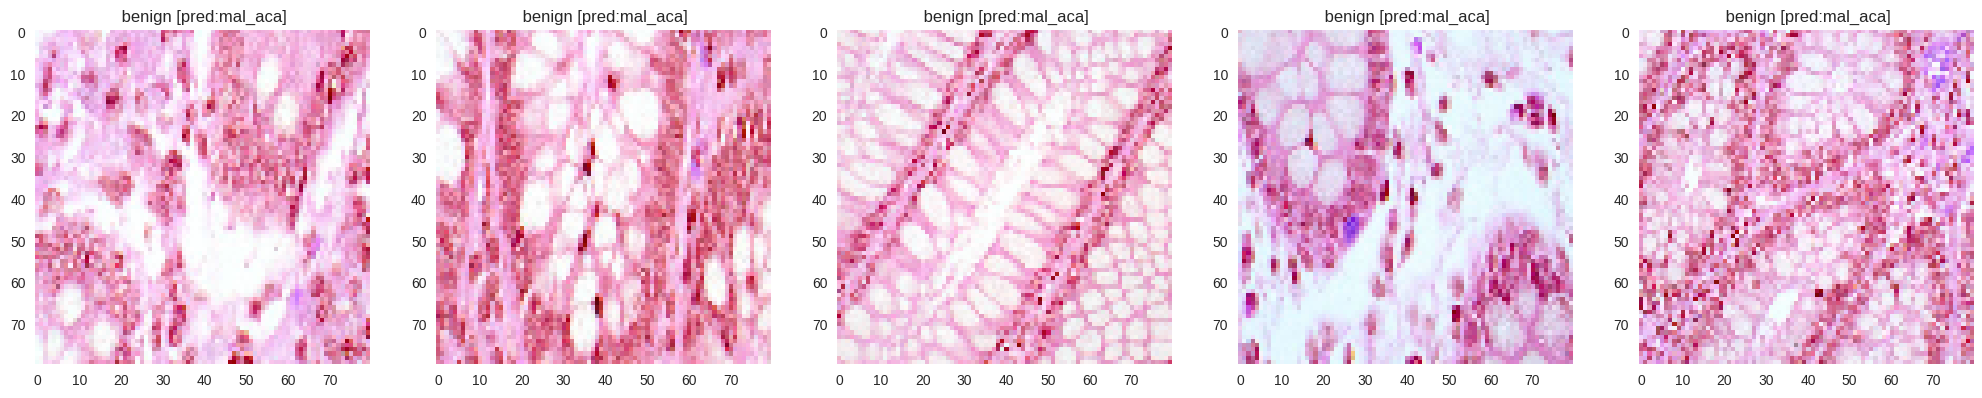

In [ ]:
mistakes = np.where(y_pred_train != y_train)[0]

n = 5

plt.figure(figsize=(5*n,5))

# get 5 random false negatives
for i, val in enumerate(np.random.choice(mistakes, n)):

    plt.subplot(1,n,i+1)
    plt.imshow(X_train[val])
    plt.title(f" {label_names[y_train[val]]} [pred:{label_names[y_pred_train[val]]}]", fontsize=12)
    plt.grid(None)


In [1]:
model.save("colon_cancer_model.h5")


NameError: name 'model' is not defined